Model 5 Code


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     116.9
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.25e-66
Time:                        23:14:47   Log-Likelihood:                -1509.9
No. Observations:                 414   AIC:                             3030.
Df Residuals:                     409   BIC:                             3050.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

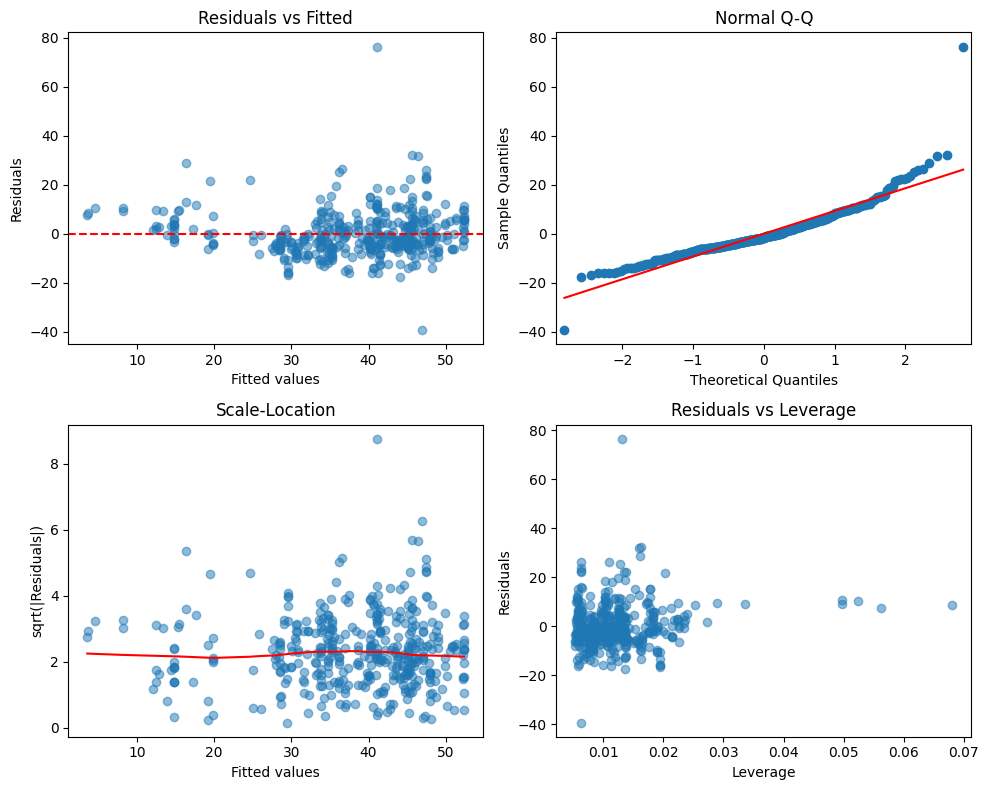

In [ ]:
#response variable: price, continuous predictor variable: distance_mrt , discrete: num_stores
# p-value < 0.05 means highly significant

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

df = pd.read_excel('/content/Real estate valuation data set 2.xlsx')


df.columns = ['No', 'transaction_date', 'house_age', 'distance_mrt',
              'num_stores', 'latitude', 'longitude', 'price']

#categorical/discrete variable I use is house age
#split house age to New (0-15), Middle (15-30) and Old > 30
def categorize_age(age):
    if age <= 15:
        return 'New'
    elif age <= 30:
        return 'Middle'
    else:
        return 'Old'

df['house_age_cat'] = df['house_age'].apply(categorize_age)

#linear model
# C means categorical
#new as a reference group to compare other groups
formula = 'price ~ C(house_age_cat, Treatment(reference="New")) + distance_mrt + num_stores'
model = smf.ols(formula, data=df).fit()

print(model.summary())


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#residual vs Fitted
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

#normality of Errors
sm.qqplot(model.resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')

#scale-location
axes[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), alpha=0.5)
smoothed = lowess(np.sqrt(np.abs(model.resid)), model.fittedvalues, frac=0.5)
axes[1, 0].plot(smoothed[:, 0], smoothed[:, 1], color='red')
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('sqrt(|Residuals|)')
axes[1, 0].set_title('Scale-Location')

#leverage plot
leverage = model.get_influence().hat_matrix_diag
axes[1, 1].scatter(leverage, model.resid, alpha=0.5)
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Leverage')

plt.tight_layout()
plt.show()

Model 5) Code For R-Squared Results

Group: New
  Slope (distance_mrt): -0.009493
  R-squared: 0.4834
------------------------------
Group: Middle
  Slope (distance_mrt): -0.005916
  R-squared: 0.6054
------------------------------
Group: Old
  Slope (distance_mrt): -0.005605
  R-squared: 0.2608
------------------------------
A) Seperate regression Lines


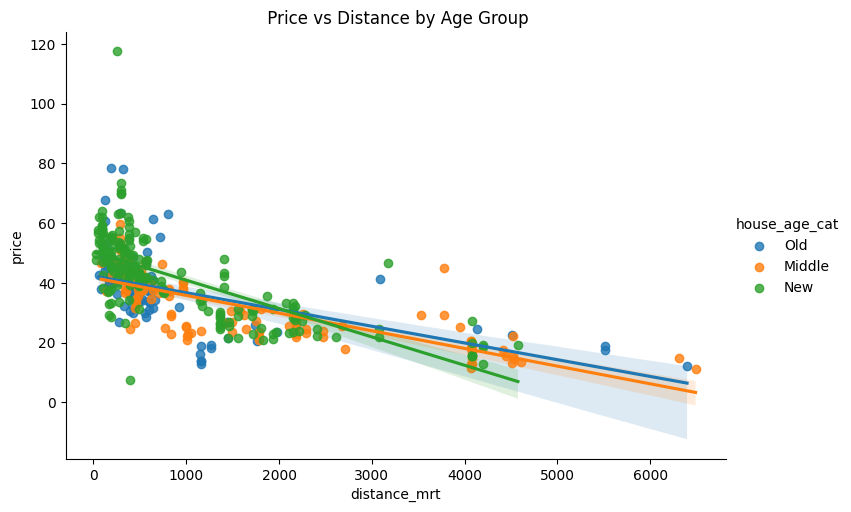

b) Single Model with Interactions
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     83.99
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.61e-60
Time:                        00:13:52   Log-Likelihood:                -1521.2
No. Observations:                 414   AIC:                             3054.
Df Residuals:                     408   BIC:                             3079.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('/content/Real estate valuation data set 2.xlsx')

#rename columns
df.columns = ['No', 'transaction_date', 'house_age', 'distance_mrt',
              'num_stores', 'latitude', 'longitude', 'price']

#categorical variable use is house_age
def categorize_age(age):
    if age <= 15: return 'New'
    elif age <= 30: return 'Middle'
    else: return 'Old'

df['house_age_cat'] = df['house_age'].apply(categorize_age)

#seperate models by house age
categories = ['New', 'Middle', 'Old']
for cat in categories:
    subset = df[df['house_age_cat'] == cat]
    #linear model
    model_sep = smf.ols('price ~ distance_mrt', data=subset).fit()
    print(f"Group: {cat}")
    print(f"  Slope (distance_mrt): {model_sep.params['distance_mrt']:.6f}")
    print(f"  R-squared: {model_sep.rsquared:.4f}")
    print("-" * 30)

#A)plot separate regression lines
print("A) Seperate regression Lines")
sns.lmplot(x='distance_mrt', y='price', hue='house_age_cat', data=df, aspect=1.5)
plt.title(' Price vs Distance by Age Group')
plt.show()

#b) single model with interactions
print("b) Single Model with Interactions")
formula_int = 'price ~ C(house_age_cat, Treatment(reference="New")) * distance_mrt'
model_int = smf.ols(formula_int, data=df).fit()

print(model_int.summary())

#c)specific interaction terms
print("")
print(" c) Specific Interaction Terms")
# These show how much the slope changes compared to the 'New' group
print(model_int.params[['C(house_age_cat, Treatment(reference="New"))[T.Middle]:distance_mrt',
                        'C(house_age_cat, Treatment(reference="New"))[T.Old]:distance_mrt']])

.

.

.

.